<a href="https://colab.research.google.com/github/PhyTorch/Machine-Learning-Lecture/blob/main/Research_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Research Challenge

<div style="background-color: #f8d7da; border-left: 6px solid #ccc; margin: 20px; padding: 15px;">
    <strong>💡 Margaret Atwood:</strong> Every aspect of human technology has a dark side, including the bow and arrow.
</div>

## 🏅 Build your own model

It is time to go back to supervised machine learning problems.

You have been assigned one dataset from [MatBench](https://matbench.materialsproject.org) as introduced in the [Lecture slides](https://speakerdeck.com/aronwalsh/mlformaterials-challenge-25). You are free to choose and tune any machine-learning model, with any Python library, but it should be appropriate for the problem. For instance, [XGBoost](https://xgboost.readthedocs.io) could be a good starting starting point to build a regression model. You can refer back to earlier notebooks and repurpose code as needed.

You may reach the limits of computing processing power on Google Colab. Building a useful model with limited resources is a real-world skill. Using other free resources is allowed if you find an alternative service, as is running on your own computer. A model tracker such as [wandb](https://wandb.ai) could be helpful for advanced users. If you want to try a brute force approach, a library such as [Automatminer](https://hackingmaterials.lbl.gov/automatminer) may be of interest.

This notebook should be used for keeping a record of your model development, submission, and even your presentation. You are free to edit (add/remove/delete) or rearrange the cells as you see fit.

### Your details

In [1]:
import numpy as np

# Insert your values
Name = "Haoyang Jiang" # Replace with your name
CID = 2213534 # Replace with your College ID (as a numeric value with no leading 0s)

# Set a random seed using the CID value
CID = int(CID)
np.random.seed(CID)

# Print the message
print("This is the work of " + Name + " [CID: " + str(CID) + "]\n")

# Define the available groups
groups = ['A', 'B', 'C', 'D', 'E']

# Select a group based on the seeded random state
challenge_group = np.random.choice(groups)

# Print the challenge code
print("Your challenge code is " + challenge_group)

This is the work of Haoyang Jiang [CID: 2213534]

Your challenge code is D


## Problem statement

You have been assigned one dataset from the [list](https://matbench.materialsproject.org/Benchmark%20Info/matbench_v0.1/) on [MatBench](https://matbench.materialsproject.org). You should state what problem you are trying to solve and comment on the best-performing model in the benchmark.

I am solving the matbench_glass task from Matbench v0.1. This is a composition-only binary classification problem where the input is chemical formula and the target variable `gfa` indicates whether a composition forms a bulk metallic glass. The official benchmark metric is ROC-AUC, and the current best public result on this task is MODNet v0.1.12 (a feed-forward neural network) with mean ROC-AUC 0.9603.

## Data preparation

Check the data distribution and apply appropriate pre-processing steps as required.

In [2]:
# Installation of libraries
!pip install matminer==0.9.3 --quiet
!pip install pymatgen --quiet
!pip install torch --quiet

In [32]:
# Import of modules
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from pymatgen.core import Composition

from matminer.datasets import load_dataset
from matminer.datasets.dataset_retrieval import get_all_dataset_info
from matminer.featurizers.composition import ElementProperty, Stoichiometry

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
  roc_auc_score,
  roc_curve,
  accuracy_score,
  balanced_accuracy_score,
  f1_score,
  confusion_matrix,
  ConfusionMatrixDisplay
)

plt.style.use("ggplot")

In [33]:
# Detailed on https://hackingmaterials.lbl.gov/matminer/dataset_summary.html
# Uncomment the info line for your assigned challenge code

  # A
#info = get_all_dataset_info("matbench_dielectric")

  # B
#info = get_all_dataset_info("matbench_expt_gap")

  # C
#info = get_all_dataset_info("matbench_expt_is_metal")

  # D
info = get_all_dataset_info("matbench_glass")

  # E
#info = get_all_dataset_info("matbench_steels")

# Check the dataset information
print(info)

Dataset: matbench_glass
Description: Matbench v0.1 test dataset for predicting full bulk metallic glass formation ability from chemical formula. Retrieved from "Nonequilibrium Phase Diagrams of Ternary Amorphous Alloys,’ a volume of the Landolt– Börnstein collection. Deduplicated according to composition, ensuring no compositions were reported as both GFA and not GFA (i.e., all reports agreed on the classification designation). For benchmarking w/ nested cross validation, the order of the dataset must be identical to the retrieved data; refer to the Automatminer/Matbench publication for more details.
Columns:
	composition: Chemical formula.
	gfa: Target variable. Glass forming ability: 1 means glass forming and corresponds to amorphous, 0 means non full glass forming.
Num Entries: 5680
Reference: Y. Kawazoe, T. Masumoto, A.-P. Tsai, J.-Z. Yu, T. Aihara Jr. (1997) Y. Kawazoe, J.-Z. Yu, A.-P. Tsai, T. Masumoto (ed.) SpringerMaterials
Nonequilibrium Phase Diagrams of Ternary Amorphous All

In [34]:
# Load your dataset into a pandas DataFrame
df = load_dataset("matbench_glass")

print(f"The full dataset contains {df.shape[0]} entries.\n")
print("The DataFrame is shown below:")
print(df)

The full dataset contains 5680 entries.

The DataFrame is shown below:
      composition    gfa
0              Al  False
1        Al(NiB)2   True
2     Al10Co21B19   True
3     Al10Co23B17   True
4     Al10Co27B13   True
...           ...    ...
5675        ZrTi9  False
5676      ZrTiSi2   True
5677      ZrTiSi3   True
5678       ZrVCo8   True
5679       ZrVNi2   True

[5680 rows x 2 columns]


In [35]:
# Inspect the dataset
print("Columns in the dataset:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass counts:")
print(df["gfa"].value_counts())

print("\nClass fractions:")
print(df["gfa"].value_counts(normalize=True))

Columns in the dataset:
Index(['composition', 'gfa'], dtype='object')

Missing values:
composition    0
gfa            0
dtype: int64

Class counts:
gfa
True     4035
False    1645
Name: count, dtype: int64

Class fractions:
gfa
True     0.710387
False    0.289613
Name: proportion, dtype: float64


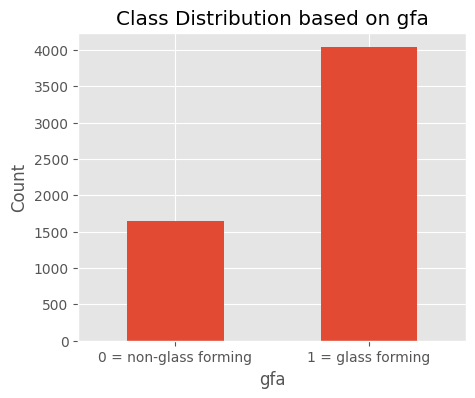

In [36]:
# Plot class balance
plt.figure(figsize=(5, 4))
df["gfa"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["0 = non-glass forming", "1 = glass forming"], rotation=0)
plt.ylabel("Count")
plt.title("Class Distribution based on gfa")
plt.show()

In [39]:
# Convert strings to pymatgen Composition objects
def add_composition_objects(df_in):
  df_out = df_in.copy()
  df_out["composition_obj"] = df_out["composition"].apply(Composition)
  return df_out

In [40]:
# Featurise composition in different ways
def build_feature_table(df_in, feature_mode="magpie"):
  """
  feature_mode:
    "magpie"       -> ElementProperty.from_preset("magpie") + Stoichiometry
    "matscholar"   -> ElementProperty.from_preset("matscholar_el") + Stoichiometry
    "meredig"      -> Meredig() + Stoichiometry
  """
  df_work = add_composition_objects(df_in)

  if feature_mode == "magpie":
    feat = ElementProperty.from_preset("magpie")
    df_feat = feat.featurize_dataframe(
      df_work, "composition_obj", ignore_errors=True, pbar=True
    )
    df_feat = Stoichiometry().featurize_dataframe(
      df_feat, "composition_obj", ignore_errors=True, pbar=True
    )

  elif feature_mode == "matscholar":
    feat = ElementProperty.from_preset("matscholar_el")
    df_feat = feat.featurize_dataframe(
      df_work, "composition_obj", ignore_errors=True, pbar=True
    )
    df_feat = Stoichiometry().featurize_dataframe(
      df_feat, "composition_obj", ignore_errors=True, pbar=True
    )

  elif feature_mode == "meredig":
    feat = Meredig()
    df_feat = feat.featurize_dataframe(
      df_work, "composition_obj", ignore_errors=True, pbar=True
    )
    df_feat = Stoichiometry().featurize_dataframe(
      df_feat, "composition_obj", ignore_errors=True, pbar=True
    )

  else:
    raise ValueError("feature_mode must be 'magpie', 'matscholar', or 'meredig'.")

  # Build X and y
  X_df = df_feat.drop(
    columns=["composition", "composition_obj", "gfa"],
    errors="ignore"
  )

  X_df = X_df.select_dtypes(include=[np.number])
  X_df = X_df.replace([np.inf, -np.inf], np.nan)

  y = df_feat["gfa"].astype(np.float32).values

  return X_df, y

In [41]:
# Build feature set A
X_magpie_df, y = build_feature_table(df, feature_mode="magpie")
print("Magpie feature shape:", X_magpie_df.shape)

/usr/local/lib/python3.12/dist-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/5680 [00:00<?, ?it/s]

Stoichiometry:   0%|          | 0/5680 [00:00<?, ?it/s]

Magpie feature shape: (5680, 138)


In [42]:
# Build feature set B
# First try matscholar-style preset; if unavailable, use Meredig
try:
  X_alt_df, y_alt = build_feature_table(df, feature_mode="matscholar")
  alt_feature_name = "matscholar_el + Stoichiometry"
except Exception as e:
  print("matscholar_el not available in this environment.")
  print("Falling back to Meredig + Stoichiometry.")
  print("Error was:", e)

  X_alt_df, y_alt = build_feature_table(df, feature_mode="meredig")
  alt_feature_name = "Meredig + Stoichiometry"

assert np.array_equal(y, y_alt)

print("Alternative feature shape:", X_alt_df.shape)
print("Alternative feature set:", alt_feature_name)

/usr/local/lib/python3.12/dist-packages/matminer/utils/data.py:584: UserWarning: MatscholarElementData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/5680 [00:00<?, ?it/s]

Stoichiometry:   0%|          | 0/5680 [00:00<?, ?it/s]

Alternative feature shape: (5680, 1006)
Alternative feature set: matscholar_el + Stoichiometry


Choose relevant features, which may be based on composition or structure, depending on your problem. [matminer](https://hackingmaterials.lbl.gov/matminer/) is a good place to start.

## Model selection, testing and training

Define your model and justify your choice based on the problem and available data. You can look back at earlier notebooks and investigate other examples online including in [scikit-learn](https://scikit-learn.org).

In [47]:
# DataLoader
def make_loader(X_array, y_array, batch_size=64, shuffle=False):
  X_tensor = torch.tensor(X_array, dtype=torch.float32)
  y_tensor = torch.tensor(y_array, dtype=torch.float32).view(-1, 1)
  dataset = TensorDataset(X_tensor, y_tensor)
  return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [46]:
# Device selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [48]:
# Define the FFNN model
class FeedForwardNN(nn.Module):
  def __init__(self, input_dim, hidden_dims=[256, 128], dropout=0.2):
    super().__init__()

    layers = []
    prev_dim = input_dim

    for hidden_dim in hidden_dims:
      layers.append(nn.Linear(prev_dim, hidden_dim))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout))
      prev_dim = hidden_dim

    layers.append(nn.Linear(prev_dim, 1))  # single logit output

    self.network = nn.Sequential(*layers)

  def forward(self, x):
    return self.network(x)

In [49]:
# Evaluation function
def evaluate_model(model, data_loader, criterion):
  model.eval()

  total_loss = 0.0
  y_true = []
  y_score = []

  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      logits = model(X_batch)
      loss = criterion(logits, y_batch)

      total_loss += loss.item() * len(y_batch)

      probs = torch.sigmoid(logits)
      y_true.extend(y_batch.cpu().numpy().ravel())
      y_score.extend(probs.cpu().numpy().ravel())

  mean_loss = total_loss / len(data_loader.dataset)
  roc_auc = roc_auc_score(y_true, y_score)

  return mean_loss, roc_auc, np.array(y_true), np.array(y_score)

In [53]:
# Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=100):

  history = {
    "train_loss": [],
    "val_loss": [],
    "val_roc_auc": []
  }

  best_val_auc = -np.inf
  best_state = None

  for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      optimizer.zero_grad()
      logits = model(X_batch)
      loss = criterion(logits, y_batch)
      loss.backward()
      optimizer.step()

      running_loss += loss.item() * len(y_batch)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_auc, _, _ = evaluate_model(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_roc_auc"].append(val_auc)

    print(
      f"Epoch {epoch+1:03d} | "
      f"Train Loss: {train_loss:.4f} | "
      f"Val Loss: {val_loss:.4f} | "
      f"Val ROC-AUC: {val_auc:.4f}"
    )

    if val_auc > best_val_auc:
      best_val_auc = val_auc
      best_state = copy.deepcopy(model.state_dict())

  model.load_state_dict(best_state)
  return model, history, best_val_auc

In [54]:
# Candidate FFNN configurations
candidate_configs = [
    {"hidden_dims": [128, 64], "dropout": 0.10, "lr": 1e-3, "weight_decay": 1e-4},
    {"hidden_dims": [256, 128], "dropout": 0.20, "lr": 1e-3, "weight_decay": 1e-4},
    {"hidden_dims": [256, 128, 64], "dropout": 0.30, "lr": 1e-3, "weight_decay": 1e-4},
]

In [56]:
# 5-fold stratifield CV
def run_cv_experiment(X_df, y, feature_name, candidate_configs, n_splits=5, cid=12345678):
  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=cid)

  fold_rows = []
  fold_artifacts = []

  for fold, (train_val_idx, test_idx) in enumerate(skf.split(X_df, y), start=1):
    print(f"\n{'='*70}")
    print(f"Feature set: {feature_name} | Fold {fold}/{n_splits}")

    X_train_val_df = X_df.iloc[train_val_idx].copy()
    X_test_df = X_df.iloc[test_idx].copy()

    y_train_val = y[train_val_idx]
    y_test = y[test_idx]

    # Inner train/validation split
    X_train_df, X_val_df, y_train, y_val = train_test_split(
      X_train_val_df,
      y_train_val,
      test_size=0.15,
      random_state=cid + fold,
      stratify=y_train_val
    )

    # Fit preprocessing on training data only
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_train = imputer.fit_transform(X_train_df)
    X_val = imputer.transform(X_val_df)
    X_test = imputer.transform(X_test_df)

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # Loaders
    train_loader = make_loader(X_train, y_train, batch_size=64, shuffle=True)
    val_loader = make_loader(X_val, y_val, batch_size=256, shuffle=False)
    test_loader = make_loader(X_test, y_test, batch_size=256, shuffle=False)

    # Class weighting for imbalance
    n_pos = y_train.sum()
    n_neg = len(y_train) - n_pos
    pos_weight_value = n_neg / max(n_pos, 1.0)
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

    best_fold_model = None
    best_fold_history = None
    best_fold_config = None
    best_val_auc = -np.inf

    input_dim = X_train.shape[1]

    for config in candidate_configs:
      print(f"Testing config: {config}")

      model = FeedForwardNN(
        input_dim=input_dim,
        hidden_dims=config["hidden_dims"],
        dropout=config["dropout"]
      ).to(device)

      criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
      optimizer = optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
      )

      model, history, val_auc = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        num_epochs=100,
      )

      print(f"Validation ROC-AUC: {val_auc:.4f}")

      if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_fold_model = model
        best_fold_history = history
        best_fold_config = config

    # Evaluate best config on this fold's test set
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    test_loss, test_roc_auc, y_true_test, y_score_test = evaluate_model(
      best_fold_model,
      test_loader,
      criterion
    )

    y_pred_test = (y_score_test >= 0.5).astype(int)

    test_accuracy = accuracy_score(y_true_test, y_pred_test)
    test_balanced_accuracy = balanced_accuracy_score(y_true_test, y_pred_test)
    test_f1 = f1_score(y_true_test, y_pred_test)

    print(f"Best config for fold {fold}: {best_fold_config}")
    print(f"Fold {fold} test ROC-AUC: {test_roc_auc:.4f}")

    fold_rows.append({
      "feature_set": feature_name,
      "fold": fold,
      "best_config": str(best_fold_config),
      "val_roc_auc": best_val_auc,
      "test_loss": test_loss,
      "test_roc_auc": test_roc_auc,
      "test_accuracy": test_accuracy,
      "test_balanced_accuracy": test_balanced_accuracy,
      "test_f1": test_f1
    })

    fold_artifacts.append({
      "feature_set": feature_name,
      "fold": fold,
      "y_true": y_true_test,
      "y_score": y_score_test,
      "y_pred": y_pred_test,
      "history": best_fold_history,
      "best_config": best_fold_config
    })

  return pd.DataFrame(fold_rows), fold_artifacts

In [57]:
# Run both featurisation
feature_tables = {
  "Magpie + Stoichiometry": X_magpie_df,
  alt_feature_name: X_alt_df
}

all_cv_results = {}
all_cv_artifacts = {}
summary_rows = []

for feature_name, X_df in feature_tables.items():
  cv_df, artifacts = run_cv_experiment(
    X_df=X_df,
    y=y,
    feature_name=feature_name,
    candidate_configs=candidate_configs,
    n_splits=5,
    cid=CID
  )

  all_cv_results[feature_name] = cv_df
  all_cv_artifacts[feature_name] = artifacts

  summary_rows.append({
    "feature_set": feature_name,
    "mean_test_roc_auc": cv_df["test_roc_auc"].mean(),
    "std_test_roc_auc": cv_df["test_roc_auc"].std(ddof=1),
    "mean_test_accuracy": cv_df["test_accuracy"].mean(),
    "mean_test_balanced_accuracy": cv_df["test_balanced_accuracy"].mean(),
    "mean_test_f1": cv_df["test_f1"].mean()
  })

summary_df = pd.DataFrame(summary_rows).sort_values(
  "mean_test_roc_auc",
  ascending=False
)

summary_df


Feature set: Magpie + Stoichiometry | Fold 1/5
Testing config: {'hidden_dims': [128, 64], 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0001}
Epoch 001 | Train Loss: 0.3380 | Val Loss: 0.2897 | Val ROC-AUC: 0.8426
Epoch 002 | Train Loss: 0.2824 | Val Loss: 0.2653 | Val ROC-AUC: 0.8638
Epoch 003 | Train Loss: 0.2646 | Val Loss: 0.2515 | Val ROC-AUC: 0.8778
Epoch 004 | Train Loss: 0.2542 | Val Loss: 0.2385 | Val ROC-AUC: 0.8905
Epoch 005 | Train Loss: 0.2459 | Val Loss: 0.2441 | Val ROC-AUC: 0.8863
Epoch 006 | Train Loss: 0.2415 | Val Loss: 0.2275 | Val ROC-AUC: 0.9021
Epoch 007 | Train Loss: 0.2320 | Val Loss: 0.2190 | Val ROC-AUC: 0.9113
Epoch 008 | Train Loss: 0.2248 | Val Loss: 0.2206 | Val ROC-AUC: 0.9080
Epoch 009 | Train Loss: 0.2203 | Val Loss: 0.2233 | Val ROC-AUC: 0.9052
Epoch 010 | Train Loss: 0.2188 | Val Loss: 0.2102 | Val ROC-AUC: 0.9153
Epoch 011 | Train Loss: 0.2153 | Val Loss: 0.2196 | Val ROC-AUC: 0.9067
Epoch 012 | Train Loss: 0.2126 | Val Loss: 0.2111 | Val ROC-AUC:

,feature_set,mean_test_roc_auc,std_test_roc_auc,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_f1
1,matscholar_el + Stoichiometry,0.919606,0.010997,0.851585,0.845669,0.891603
0,Magpie + Stoichiometry,0.918131,0.007394,0.844366,0.838968,0.885970


In [61]:
for feature_name, cv_df in all_cv_results.items():
  print("\n")
  print(feature_name)
  display(cv_df)



Magpie + Stoichiometry


,feature_set,fold,best_config,val_roc_auc,test_loss,test_roc_auc,test_accuracy,test_balanced_accuracy,test_f1
0,Magpie + Stoichiometry,1,"{'hidden_dims': [256, 128, 64], 'dropout': 0.3...",0.939832,0.222465,0.912536,0.827465,0.829953,0.871560
1,Magpie + Stoichiometry,2,"{'hidden_dims': [256, 128], 'dropout': 0.2, 'l...",0.941590,0.234559,0.925327,0.853873,0.846740,0.893590
2,Magpie + Stoichiometry,3,"{'hidden_dims': [128, 64], 'dropout': 0.1, 'lr...",0.932496,0.308743,0.908385,0.841549,0.830864,0.884763
3,Magpie + Stoichiometry,4,"{'hidden_dims': [256, 128], 'dropout': 0.2, 'l...",0.937803,0.228817,0.924133,0.838028,0.834687,0.880829
4,Magpie + Stoichiometry,5,"{'hidden_dims': [256, 128], 'dropout': 0.2, 'l...",0.931286,0.282422,0.920276,0.860915,0.852597,0.899106




matscholar_el + Stoichiometry


,feature_set,fold,best_config,val_roc_auc,test_loss,test_roc_auc,test_accuracy,test_balanced_accuracy,test_f1
0,matscholar_el + Stoichiometry,1,"{'hidden_dims': [128, 64], 'dropout': 0.1, 'lr...",0.926147,0.265491,0.915306,0.850352,0.838861,0.891582
1,matscholar_el + Stoichiometry,2,"{'hidden_dims': [128, 64], 'dropout': 0.1, 'lr...",0.933530,0.257954,0.923498,0.854754,0.846459,0.894434
2,matscholar_el + Stoichiometry,3,"{'hidden_dims': [128, 64], 'dropout': 0.1, 'lr...",0.930274,0.354730,0.902724,0.857394,0.843817,0.897208
3,matscholar_el + Stoichiometry,4,"{'hidden_dims': [128, 64], 'dropout': 0.1, 'lr...",0.928448,0.229323,0.931044,0.845070,0.855847,0.883905
4,matscholar_el + Stoichiometry,5,"{'hidden_dims': [128, 64], 'dropout': 0.1, 'lr...",0.926956,0.252528,0.925458,0.850352,0.843361,0.890886


Train, validate and test your model. Make sure to do proper data splits and to consider the hyperparamaters of your model.

<details>
<summary>Note on the ROC-AUC classification metric</summary>
There is one metric we didn't cover but is used in Matbench. In binary classification models, the ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) score can be used to evaluate performance. It quantifies the ability of the model to distinguish between positive and negative instances across different decision thresholds. A higher ROC-AUC score (ranging from 0.5 to 1) indicates better performance, with 1 representing a perfect classifier and 0.5 indicating performance no better than random chance. There is a more detailed discussion here: https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc.

The metric can be calculated using the `roc_auc_score` function from the `sklearn.metrics` module, e.g.

```python
from sklearn.metrics import roc_auc_score

# Assuming you have true labels (y_true) and predicted probabilities (y_pred_prob)
y_true = [...]  
y_pred_prob = [...]  

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_true, y_pred_prob)

# Display the result
print(f'ROC-AUC Score: {roc_auc:.4f}')
```
</details>

## Model analysis and discussion

How well does your final model perform? Think of metrics and plots that are useful to dig a little deeper.

Compare against the best-performing model on the [MatBench](https://matbench.materialsproject.org) leaderboard.  With limited resources, don't expect to match this performance, but you should do better than a baseline model.

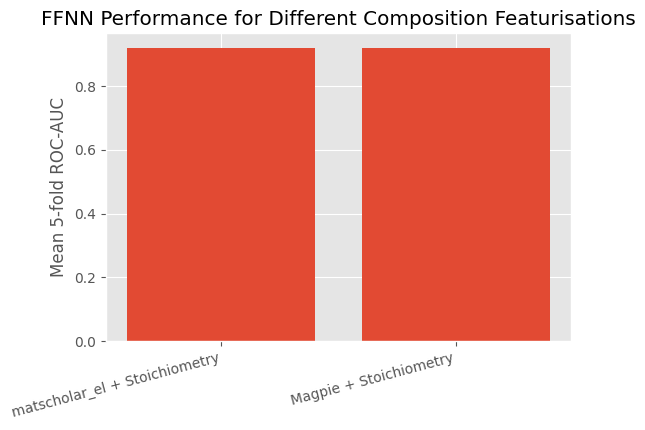

In [62]:
plt.figure(figsize=(6, 4))
plt.bar(summary_df["feature_set"], summary_df["mean_test_roc_auc"])
plt.ylabel("Mean 5-fold ROC-AUC")
plt.title("FFNN Performance for Different Composition Featurisations")
plt.xticks(rotation=15, ha="right")
plt.show()

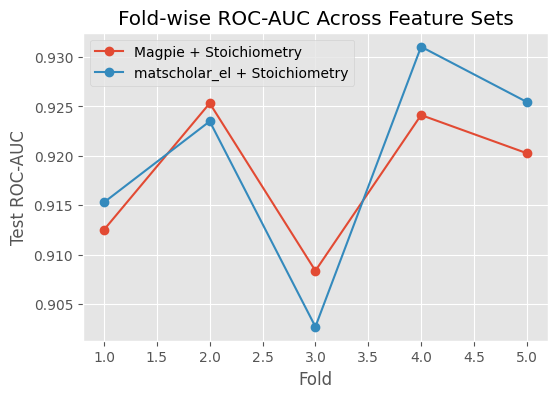

In [64]:
plt.figure(figsize=(6, 4))
for feature_name, cv_df in all_cv_results.items():
  plt.plot(
    cv_df["fold"],
    cv_df["test_roc_auc"],
    marker="o",
    label=feature_name
  )

plt.xlabel("Fold")
plt.ylabel("Test ROC-AUC")
plt.title("Fold-wise ROC-AUC Across Feature Sets")
plt.legend()
plt.show()

In [65]:
best_feature_set = summary_df.iloc[0]["feature_set"]
print("Best feature set:", best_feature_set)

best_cv_df = all_cv_results[best_feature_set]
best_artifacts = all_cv_artifacts[best_feature_set]

display(best_cv_df)

Best feature set: matscholar_el + Stoichiometry


,feature_set,fold,best_config,val_roc_auc,test_loss,test_roc_auc,test_accuracy,test_balanced_accuracy,test_f1
0,matscholar_el + Stoichiometry,1,"{'hidden_dims': [128, 64], 'dropout': 0.1, 'lr...",0.926147,0.265491,0.915306,0.850352,0.838861,0.891582
1,matscholar_el + Stoichiometry,2,"{'hidden_dims': [128, 64], 'dropout': 0.1, 'lr...",0.933530,0.257954,0.923498,0.854754,0.846459,0.894434
2,matscholar_el + Stoichiometry,3,"{'hidden_dims': [128, 64], 'dropout': 0.1, 'lr...",0.930274,0.354730,0.902724,0.857394,0.843817,0.897208
3,matscholar_el + Stoichiometry,4,"{'hidden_dims': [128, 64], 'dropout': 0.1, 'lr...",0.928448,0.229323,0.931044,0.845070,0.855847,0.883905
4,matscholar_el + Stoichiometry,5,"{'hidden_dims': [128, 64], 'dropout': 0.1, 'lr...",0.926956,0.252528,0.925458,0.850352,0.843361,0.890886


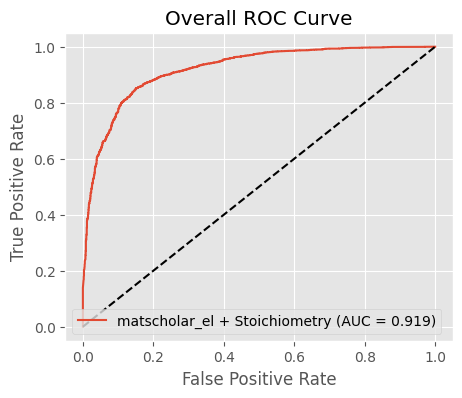

In [68]:
y_true_all = np.concatenate([item["y_true"] for item in best_artifacts])
y_score_all = np.concatenate([item["y_score"] for item in best_artifacts])

overall_auc = roc_auc_score(y_true_all, y_score_all)
fpr, tpr, _ = roc_curve(y_true_all, y_score_all)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"{best_feature_set} (AUC = {overall_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Overall ROC Curve")
plt.legend()
plt.show()

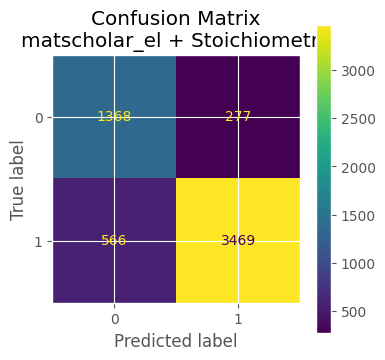

In [70]:
y_pred_all = (y_score_all >= 0.5).astype(int)

cm = confusion_matrix(y_true_all, y_pred_all)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax)
plt.title(f"Confusion Matrix\n{best_feature_set}")
plt.show()

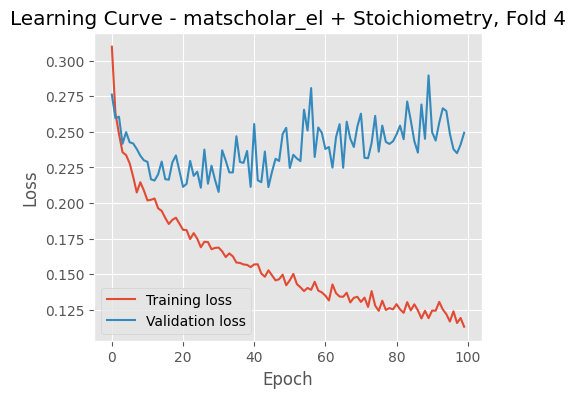

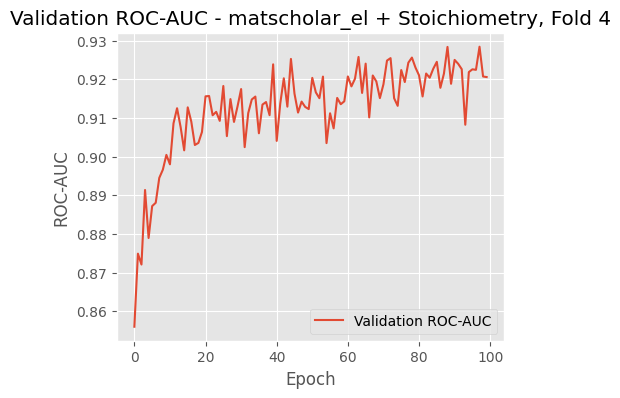

In [72]:
best_fold_idx = best_cv_df["test_roc_auc"].idxmax()
best_fold_number = int(best_cv_df.loc[best_fold_idx, "fold"])

best_fold_artifact = None
for item in best_artifacts:
    if item["fold"] == best_fold_number:
        best_fold_artifact = item
        break

history = best_fold_artifact["history"]

plt.figure(figsize=(5, 4))
plt.plot(history["train_loss"], label="Training loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Learning Curve - {best_feature_set}, Fold {best_fold_number}")
plt.legend()
plt.show()

plt.figure(figsize=(5, 4))
plt.plot(history["val_roc_auc"], label="Validation ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title(f"Validation ROC-AUC - {best_feature_set}, Fold {best_fold_number}")
plt.legend()
plt.show()

## Large Language Model (LLM) usage declaration

Acknowledge use of a generative model during your assignment. Points to consider:

* State which LLM (e.g. GPT-4, Gemini, Co-Pilot)

* Specify tasks (e.g. summarising research or code snippets)

* Were any limitations/biases noted?

* How did you ensure ethical use?

In [28]:
# LLM usage declaration
#
# I used ChatGPT-5.4 to help me:
# 1. explain and fixing errors,
# 2. refine code documentations,
# 3. explain machine-learning concepts such as ROC-AUC.
#
# TO ensure ethical use:
# I did not use LLM to generate any code from scratch;
# I validated all generated code fixes and explanations manually before using them.

## ☘️ Final word

Good luck building your own model! We hope that you enjoyed the course and exercises. Dive deeper into the aspects that caught your interest. A useful starting point may be the [Resources](https://aronwalsh.github.io/MLforMaterials/Resources.html) page.

Remember that submission is on Blackboard and you should upload both the completed Juypter Notebook (`.ipynb` file), as well as your recorded narrated presentation (maximum 5 minutes; see guides on using [Zoom](https://www.youtube.com/watch?v=H9qhoAIzW3E) or [Powerpoint](https://www.youtube.com/watch?v=Y5dgwwa5XRA) for this purpose).